<h1 style="color:#56B4E9;">Week 5 - Day 1</h1>

<h2 style="color:#0072B2;">Unsupervised Learning & K-Means Clustering</h2>

<h3 style="color:#009E73;">Discovering Patient Profiles Without Diagnosis Labels</h3>

The Cleveland Heart Disease dataset was previously used in Project 1 as a supervised classification problem.

In that project, patient clinical and test-related features were used to predict a known heart-disease target.

In this notebook, the same dataset is approached from a completely different perspective:

**What structure can we discover if the diagnosis label is not used?**

Instead of predicting heart disease, we will investigate whether patients naturally form groups based on similarities in their clinical measurements.

The workflow will include:

- Selecting appropriate features for distance-based clustering.
- Scaling the clinical measurements.
- Understanding how K-Means forms clusters.
- Choosing the number of clusters using the Elbow Method.
- Validating candidate values of k using the Silhouette Score.
- Interpreting the clinical profile represented by each discovered cluster.

<span style="color:#009E73;"><b>Main goal:</b></span>  
Reuse the Project 1 dataset to move from supervised prediction to unsupervised discovery and identify natural patient profiles without using the diagnosis label.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

In [2]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

data = pd.read_csv(
    "../../processed.cleveland.data",
    header=None,
    names=column_names
)

data = data.replace("?", np.nan)

data["ca"] = pd.to_numeric(data["ca"], errors="coerce")
data["thal"] = pd.to_numeric(data["thal"], errors="coerce")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<h2 style="color:#0072B2;">From Prediction to Discovery</h2>

In Project 1, the Cleveland Heart Disease dataset was treated as a supervised-learning problem.

Each patient had:

**X = patient features**

and

**y = known heart-disease outcome**

The model therefore learned patterns that helped predict a predefined diagnosis.

In this Week 5 experiment, the target is intentionally removed from the learning process.

K-Means receives only patient characteristics and attempts to discover structure based on similarities between patients.

This changes the question from:

**"Can these features predict heart disease?"**

to:

**"Do patients naturally form groups with similar clinical profiles?"**

<span style="color:#009E73;"><b>Key idea:</b></span>  
We are using the same data for a different machine-learning objective. A cluster is not a diagnosis or a predefined class; its meaning must be interpreted after clustering.

<h2 style="color:#0072B2;">Selecting Features for Distance-Based Clustering</h2>

K-Means groups observations according to distance.

Therefore, numeric storage alone is not enough to make a feature appropriate for direct use in K-Means.

Several Cleveland features such as `cp`, `restecg`, `slope`, and `thal` use numbers as category codes. Treating the difference between these codes as a real numerical distance would introduce artificial relationships.

For the initial clustering experiment, we will therefore focus on measurement and discrete-numeric features for which numerical distance has a meaningful interpretation.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Use `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, and `ca` for the initial K-Means analysis, while excluding the diagnosis target and categorical codes.

In [3]:
clustering_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

X = data[clustering_features].copy()

print("Clustering data shape:", X.shape)
print("\nMissing values:")
print(X.isna().sum())

Clustering data shape: (303, 6)

Missing values:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
ca          4
dtype: int64


<h2 style="color:#0072B2;">How Does K-Means Define Similar Patients?</h2>

K-Means represents each patient as a point in a multidimensional feature space.

To measure similarity, it uses distance.

For a patient $x_i$ and a cluster centroid $\mu_j$, the Euclidean distance is:

$$
d(x_i,\mu_j)
=
\sqrt{
\sum_{m=1}^{p}
(x_{im}-\mu_{jm})^2
}
$$

A patient is assigned to the cluster whose centroid is closest.

The centroid itself is the mean position of the observations currently assigned to that cluster.

<span style="color:#009E73;"><b>Key idea:</b></span>  
K-Means turns the idea of "similar patients" into a distance problem: patients with similar feature values should lie close together in feature space.

<h2 style="color:#0072B2;">The K-Means Assignment–Update Loop</h2>

For a chosen number of clusters $k$, K-Means repeats two main steps:

### 1. Assignment

Each patient is assigned to the nearest centroid:

$$
c_i = \arg\min_j \|x_i-\mu_j\|^2
$$

### 2. Centroid Update

Each centroid is updated to the mean position of the patients assigned to that cluster:

$$
\mu_j =
\frac{1}{|C_j|}
\sum_{x_i \in C_j} x_i
$$

These two steps repeat until the assignments and centroid positions become stable.

K-Means therefore tries to minimize the total within-cluster squared distance:

$$
J =
\sum_{j=1}^{k}
\sum_{x_i \in C_j}
\|x_i-\mu_j\|^2
$$

In Scikit-learn, this quantity is reported as **inertia**.

<span style="color:#009E73;"><b>Connection forward:</b></span>  
This is why inertia will later be used in the Elbow Method to help choose an appropriate value of $k$.

<h2 style="color:#0072B2;">Preparing the Features for Distance-Based Clustering</h2>

Before K-Means can calculate meaningful distances, two data-quality problems must be handled.

### Missing Values

The selected feature `ca` contains four missing observations.

K-Means requires a complete numeric matrix, so these values must be handled before clustering.

Because `ca` is a discrete numeric count and only a small number of observations are missing, median imputation will be used.

### Different Feature Scales

The selected clinical variables are measured using different units and numerical ranges.

Without scaling, features with larger numerical ranges could dominate the Euclidean distance and therefore dominate the clustering result.

StandardScaler transforms each feature approximately as:

$$
z = \frac{x-\mu}{\sigma}
$$

<span style="color:#D55E00;"><b>Decision:</b></span>  
Impute missing numeric values first, then standardize all clustering features before fitting K-Means.

In [4]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Missing values after imputation:")
print(X_imputed.isna().sum())

Missing values after imputation:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
ca          0
dtype: int64


In [5]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

X_scaled.describe().loc[["mean", "std"]].round(2)

,age,trestbps,chol,thalach,oldpeak,ca
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


<h2 style="color:#0072B2;">First K-Means Experiment</h2>

Before searching for the best number of clusters, we will first fit K-Means with an initial value of:

$$
k = 3
$$

This is only an exploratory starting point.

It does **not** mean that three clusters are assumed to be the correct structure of the patient population.

The purpose of this experiment is to observe the clustering output before systematically selecting \(k\).

In [6]:
kmeans_initial = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

initial_labels = kmeans_initial.fit_predict(X_scaled)

print("Cluster assignments:")
print(pd.Series(initial_labels).value_counts().sort_index())

print("\nInertia:")
print(round(kmeans_initial.inertia_, 2))

Cluster assignments:
0     94
1    117
2     92
Name: count, dtype: int64

Inertia:
1217.66


<h2 style="color:#0072B2;">Choosing the Number of Clusters: The Elbow Method</h2>

K-Means requires the number of clusters \(k\) to be chosen before fitting the model.

A smaller inertia means that patients are, on average, closer to the centroids of their assigned clusters.

However, inertia cannot be minimized blindly.

As \(k\) increases, K-Means receives more centroids and can always create more compact groups. In the extreme case where every observation forms its own cluster, inertia would approach zero but the clustering would have little practical meaning.

The Elbow Method therefore looks for the point where adding another cluster produces only a relatively small improvement in inertia.

<span style="color:#009E73;"><b>Key idea:</b></span>  
We are not looking for the lowest inertia. We are looking for a useful balance between cluster compactness and model complexity.

In [7]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

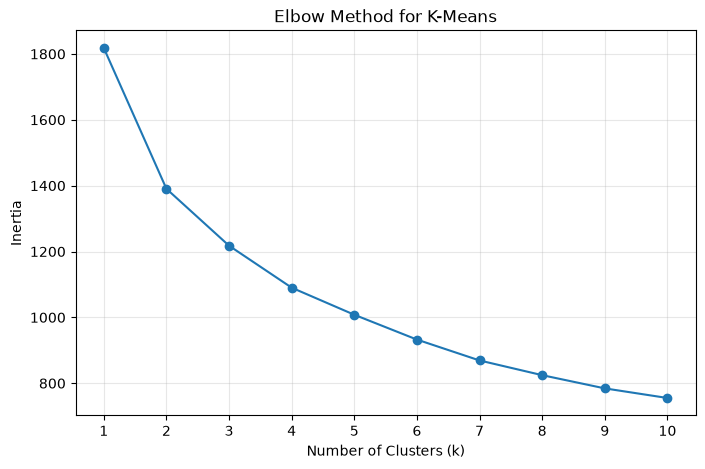

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xticks(k_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.grid(alpha=0.3)
plt.show()

<h2 style="color:#0072B2;">Validating k with the Silhouette Score</h2>

The Elbow Method is useful, but the location of the elbow may not always be visually obvious.

The Silhouette Score provides a more quantitative way to evaluate cluster quality.

For each observation, it compares:

- \(a(i)\): how close the observation is to points inside its own cluster.
- \(b(i)\): how close the observation is to the nearest alternative cluster.

The silhouette value is:

$$
s(i) =
\frac{b(i)-a(i)}
{\max(a(i),b(i))}
$$

The score ranges from -1 to +1:

- Close to **+1**: well matched to its own cluster and separated from others.
- Around **0**: close to a boundary between clusters.
- Below **0**: potentially assigned to the wrong cluster.

<span style="color:#009E73;"><b>Key idea:</b></span>  
Inertia measures compactness, while the Silhouette Score also considers separation between clusters.

In [9]:
candidate_k_values = [2, 3]

silhouette_results = {}

for k in candidate_k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_results[k] = score

for k, score in silhouette_results.items():
    print(f"k = {k}: Silhouette Score = {score:.3f}")

k = 2: Silhouette Score = 0.232
k = 3: Silhouette Score = 0.180


<h2 style="color:#0072B2;">Selecting the Final Number of Clusters</h2>

The Elbow Method identified a small set of reasonable values for \(k\), and the top candidates were then compared using the Silhouette Score.

Among the tested candidates, \(k=2\) produced the higher Silhouette Score.

This indicates that two clusters provide a better balance between:

- Keeping patients relatively close to others in the same cluster.
- Separating them from patients in the nearest alternative cluster.

However, the Silhouette Score is still relatively modest, indicating that the patient groups are not perfectly separated.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Use \(k=2\) for the final K-Means model, while interpreting the result as two broad and partially overlapping patient profiles rather than perfectly separated clinical groups.

In [10]:
final_k = 2

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

cluster_counts = pd.Series(
    final_labels,
    name="cluster"
).value_counts().sort_index()

print("Patients per cluster:")
print(cluster_counts)

print("\nFinal inertia:")
print(round(final_kmeans.inertia_, 2))

Patients per cluster:
cluster
0    131
1    172
Name: count, dtype: int64

Final inertia:
1390.48


<h2 style="color:#0072B2;">Profiling the Discovered Clusters</h2>

The cluster labels themselves have no predefined meaning.

To understand what K-Means discovered, the clusters must be compared using the original clinical units.

The model was fitted using standardized values, but interpretation is easier using the imputed data before scaling.

For each cluster, we will therefore calculate the average value of every feature used during clustering.

<span style="color:#009E73;"><b>Key idea:</b></span>  
K-Means discovers the groups. Cluster profiling gives those groups an interpretable meaning.

In [11]:
clustered_data = X_imputed.copy()
clustered_data["cluster"] = final_labels

cluster_profiles = (
    clustered_data
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_profiles

,age,trestbps,chol,thalach,oldpeak,ca
cluster,,,,,,
0,60.84,137.34,258.79,134.68,1.72,1.27
1,49.56,127.39,237.48,160.98,0.52,0.20


<h2 style="color:#0072B2;">Visualizing a Six-Dimensional Clustering Result</h2>

The final K-Means model was fitted using six features:

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`
- `ca`

This means that the actual clustering exists in a six-dimensional feature space.

A six-dimensional geometric space cannot be displayed directly on a standard 2D screen.

For this reason, two complementary visualizations will be used:

1. A 2D scatter plot to inspect the clusters from one interpretable perspective.
2. A standardized cluster-profile plot to compare the clusters across all six features simultaneously.

<span style="color:#009E73;"><b>Important:</b></span>  
Neither visualization replaces the original six-dimensional clustering. They are different views used to help interpret the structure learned by K-Means.

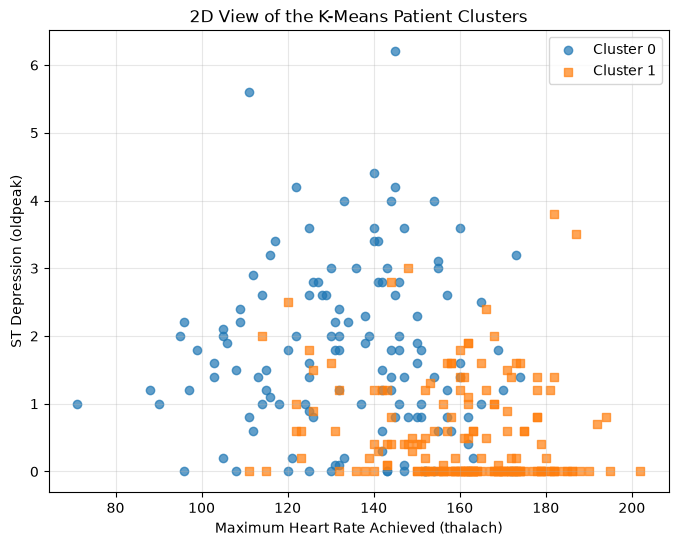

In [12]:
plot_data = X_imputed.copy()
plot_data["cluster"] = final_labels

markers = {
    0: "o",
    1: "s"
}

plt.figure(figsize=(8, 6))

for cluster_id in sorted(plot_data["cluster"].unique()):
    
    cluster_points = plot_data[
        plot_data["cluster"] == cluster_id
    ]
    
    plt.scatter(
        cluster_points["thalach"],
        cluster_points["oldpeak"],
        marker=markers[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.xlabel("Maximum Heart Rate Achieved (thalach)")
plt.ylabel("ST Depression (oldpeak)")
plt.title("2D View of the K-Means Patient Clusters")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [13]:
scaled_cluster_data = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X.index
)

scaled_cluster_data["cluster"] = final_labels

standardized_profiles = (
    scaled_cluster_data
    .groupby("cluster")
    .mean()
)

standardized_profiles

,age,trestbps,chol,thalach,oldpeak,ca
cluster,,,,,,
0,0.709324,0.321337,0.233950,-0.653664,0.587501,0.647286
1,-0.540241,-0.244739,-0.178183,0.497849,-0.447458,-0.492991


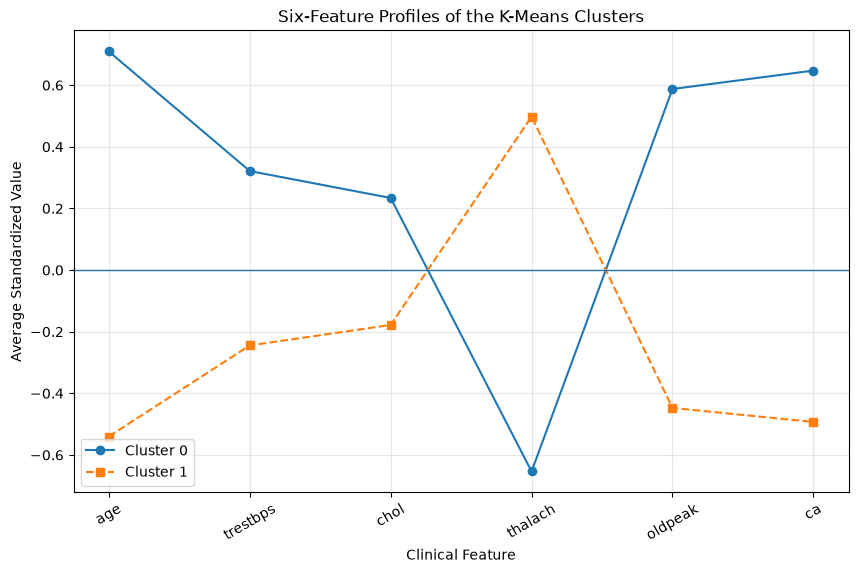

In [14]:
plt.figure(figsize=(10, 6))

markers = {
    0: "o",
    1: "s"
}

line_styles = {
    0: "-",
    1: "--"
}

for cluster_id in standardized_profiles.index:
    
    plt.plot(
        clustering_features,
        standardized_profiles.loc[cluster_id],
        marker=markers[cluster_id],
        linestyle=line_styles[cluster_id],
        label=f"Cluster {cluster_id}"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Clinical Feature")
plt.ylabel("Average Standardized Value")
plt.title("Six-Feature Profiles of the K-Means Clusters")

plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h2 style="color:#0072B2;">Interpreting the Patient Clusters</h2>

The cluster profiles reveal systematic differences across the clinical measurements used by K-Means.

### Cluster 0

Patients in Cluster 0 tend to have:

- Higher age.
- Higher resting blood pressure.
- Higher cholesterol.
- Lower maximum achieved heart rate.
- Higher exercise-related ST depression (`oldpeak`).
- Higher values of `ca`.

### Cluster 1

Patients in Cluster 1 show the opposite general profile:

- Lower age.
- Lower resting blood pressure.
- Lower cholesterol.
- Higher maximum achieved heart rate.
- Lower `oldpeak`.
- Lower `ca`.

The six-feature profile shows that the separation is not driven by a single variable. Instead, K-Means identified a broader combination of differences across several clinical measurements.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The algorithm discovered two broad patient profiles from the clinical measurements alone. However, the modest Silhouette Score indicates that these profiles still overlap considerably.

<span style="color:#D55E00;"><b>Important limitation:</b></span>  
These clusters are not diagnostic classes. The heart-disease target `num` was excluded from the clustering process, so Cluster 0 and Cluster 1 should not automatically be interpreted as "heart disease" and "no heart disease."

<h2 style="color:#0072B2;">Day 1 Conclusion</h2>

This notebook reused the Cleveland Heart Disease dataset for an unsupervised-learning problem rather than a supervised prediction task.

The diagnosis target was excluded, and K-Means was used to discover natural structure from selected clinical measurements.

The main decisions were:

- Use only features for which numerical distance has a meaningful interpretation.
- Handle missing values before clustering.
- Standardize the features because K-Means is distance-based.
- Use the Elbow Method to identify reasonable candidate values of \(k\).
- Use the Silhouette Score to compare the strongest candidates.
- Select \(k=2\) as the final clustering configuration.
- Interpret the resulting groups using their original clinical measurements.

The final clusters showed different average patient profiles across several features, rather than separation being driven by only one measurement.

However, the relatively modest Silhouette Score indicates that the groups overlap and should not be treated as sharply separated clinical categories.

<span style="color:#009E73;"><b>Final takeaway:</b></span>  
K-Means can reveal structure in data even when no target label is available, but discovering clusters is only the first step. Their quality must be validated quantitatively and their meaning must be interpreted using the original problem context.